In [ ]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src._config import DEFAULT_DATASET_DIR, DEFAULT_N_JOBS, DEFAULT_VIDEO_DIR, LABEL_ORDER

for _var in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[_var] = str(DEFAULT_N_JOBS)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_ALLOC_CONF"] = (
    "expandable_segments:True,garbage_collection_threshold:0.6"
)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import supervision as sv
import torch
from accelerate import Accelerator
from IPython.display import Image, display
from transformers import Sam3VideoConfig, Sam3VideoModel, Sam3VideoProcessor

from src.tracking.viz import _decode_rle_mask, _read_video_frames_batch
from src.utils.io import get_video_metadata, load_video_frames_sequential

device = Accelerator().device
config = Sam3VideoConfig.from_pretrained("facebook/sam3")
model = Sam3VideoModel.from_pretrained("facebook/sam3", config=config).to(
    device, dtype=torch.bfloat16
)
processor = Sam3VideoProcessor.from_pretrained("facebook/sam3")

ROOT = Path.cwd().parent
DS = ROOT / DEFAULT_DATASET_DIR
VIDEOS = ROOT / DEFAULT_VIDEO_DIR

CLASS_ORDER = [l for l in LABEL_ORDER if l != "social"]
CLASS_HEX = {"none": "#BBBBBB", "worm": "#E69F00", "locomotor": "#56B4E9"}
CLASS_IDX = {label: i for i, label in enumerate(CLASS_ORDER)}
DISPLAY_LABEL = {"none": "No-play"}
PALETTE = sv.ColorPalette.from_hex([CLASS_HEX[label] for label in CLASS_ORDER])

collage_subjects = [
    {"video_id": "C5G1D28", "frame_idx": 3688, "bird_id": 2787},
]


def video_for(video_id: str) -> Path:
    day_dir = VIDEOS / f"day_{video_id[5:]}"
    return next(day_dir.glob(f"{video_id[:4]}_*.mp4"))

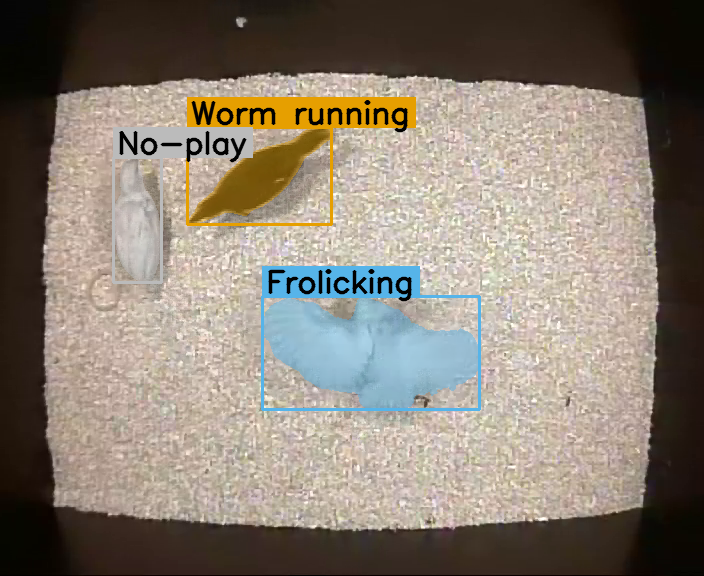

In [2]:
filters = [
    [("video_id", "==", spec["video_id"]), ("frame_idx", "==", int(spec["frame_idx"]))]
    for spec in collage_subjects
]
tracks = pd.read_parquet(
    DS / "tracks.parquet",
    columns=["video_id", "bird_id", "frame_idx", "window", "bbox", "counts", "size"],
    filters=filters,
)
labels = pd.read_parquet(
    DS / "labels.parquet",
    columns=["video_id", "bird_id", "window", "behav", "behav_label"],
)
all_rows = tracks.merge(labels, on=["video_id", "bird_id", "window"], how="left")

frames = {}
for video_id, group in all_rows.groupby("video_id"):
    want = sorted(group.frame_idx.unique().tolist())
    got = _read_video_frames_batch(video_for(video_id), want)
    frames.update({(video_id, frame_idx): image for frame_idx, image in got.items()})

mask_annotator = sv.MaskAnnotator(color=PALETTE, opacity=0.45)
box_annotator = sv.BoxAnnotator(color=PALETTE, thickness=2)
label_annotator = sv.LabelAnnotator(
    color=PALETTE,
    text_color=sv.Color.BLACK,
    text_scale=1.0,
    text_thickness=2,
    text_padding=4,
    text_position=sv.Position.TOP_LEFT,
)


def annotate_full_frame(spec: dict) -> np.ndarray:
    video_id = spec["video_id"]
    frame_idx = spec["frame_idx"]

    frame_rows = all_rows[
        (all_rows.video_id == video_id) & (all_rows.frame_idx == frame_idx)
    ]
    scene = frames[(video_id, int(frame_idx))].copy()

    xyxy_list, mask_list, class_ids, label_texts = [], [], [], []
    for _, row in frame_rows.iterrows():
        mask = _decode_rle_mask(row.counts, [int(x) for x in row["size"]]).astype(bool)
        xyxy_list.append(row.bbox)
        mask_list.append(mask)
        class_ids.append(CLASS_IDX.get(row.behav_label, 0))
        label_texts.append(DISPLAY_LABEL.get(row.behav_label, row.behav))

    detections = sv.Detections(
        xyxy=np.array(xyxy_list),
        mask=np.array(mask_list),
        class_id=np.array(class_ids),
    )
    scene = mask_annotator.annotate(scene=scene, detections=detections)
    scene = box_annotator.annotate(scene=scene, detections=detections)
    scene = label_annotator.annotate(
        scene=scene, detections=detections, labels=label_texts
    )
    return scene


for spec in collage_subjects:
    scene = annotate_full_frame(spec)
    _, buf = cv2.imencode(".png", scene)
    display(Image(data=buf.tobytes()))

In [ ]:
video_path = VIDEOS / "day_28/C1G1_Test_1_day_28_1_Camera_4_2025_02_04_10_59_56_1.mp4"
FRAME_START = 25 * 5  # 5 seconds in at 25 fps
FRAME_IDX = 200

fps, total = get_video_metadata(video_path)
n_frames = min(round(fps * 60), max(0, total - FRAME_START))
video_frames = load_video_frames_sequential(
    video_path, FRAME_START, FRAME_START + n_frames
)

inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.bfloat16,
)
inference_session = processor.add_text_prompt(
    inference_session=inference_session,
    text="bird",
)

outputs_per_frame = {}
for model_outputs in model.propagate_in_video_iterator(
    inference_session=inference_session,
    max_frame_num_to_track=FRAME_IDX,
):
    outputs_per_frame[model_outputs.frame_idx] = processor.postprocess_outputs(
        inference_session, model_outputs
    )

print(f"Tracked {len(outputs_per_frame)} frames")

  0%|          | 0/201 [00:00<?, ?it/s]

kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Tracked 201 frames


In [4]:
def label_with_supervision(
    frame_index: int,
    outputs_per_frame: dict,
    video_frames: np.ndarray,
    *,
    show_masks: bool = True,
    show_boxes: bool = True,
    show_labels: bool = True,
    mask_opacity: float = 0.5,
    box_thickness: int = 2,
) -> np.ndarray:
    frame = video_frames[frame_index]
    frame_outputs = outputs_per_frame[frame_index]

    masks = frame_outputs["masks"].detach().cpu()
    if masks.ndim == 3:
        masks = masks.unsqueeze(1)
    masks = masks.to(torch.uint8)

    object_ids = frame_outputs["object_ids"].detach().cpu()
    transformers_results = {
        "boxes": frame_outputs["boxes"].detach().cpu(),
        "masks": masks,
        "labels": object_ids,
        "scores": frame_outputs["scores"].detach().cpu(),
    }
    id2label = {int(i): f"id:{int(i)}" for i in object_ids.numpy()}

    detections = sv.Detections.from_transformers(
        transformers_results=transformers_results,
        id2label=id2label,
    )

    annotated = frame.copy()
    if show_masks:
        annotated = sv.MaskAnnotator(opacity=mask_opacity).annotate(
            scene=annotated, detections=detections
        )
    if show_boxes:
        annotated = sv.BoxAnnotator(thickness=box_thickness).annotate(
            scene=annotated, detections=detections
        )
    if show_labels:
        labels = [
            f"{class_name} {confidence:.2f}"
            for class_name, confidence in zip(
                detections["class_name"], detections.confidence
            )
        ]
        annotated = sv.LabelAnnotator().annotate(
            scene=annotated, detections=detections, labels=labels
        )
    return annotated

(np.float64(-0.5), np.float64(703.5), np.float64(575.5), np.float64(-0.5))

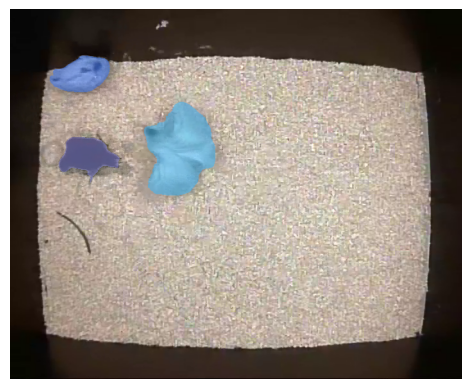

In [ ]:
annotated_masks = label_with_supervision(
    FRAME_IDX,
    outputs_per_frame,
    video_frames,
    show_boxes=False,
    show_labels=False,
)
plt.imshow(annotated_masks)
plt.axis("off")

(np.float64(-0.5), np.float64(703.5), np.float64(575.5), np.float64(-0.5))

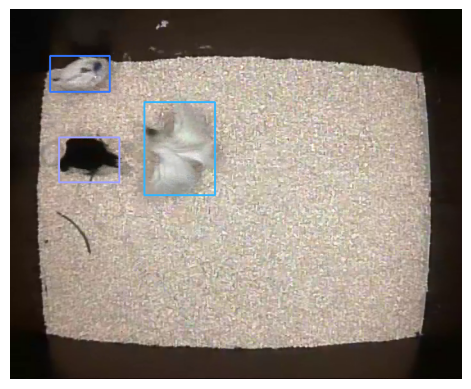

In [ ]:
annotated_boxes = label_with_supervision(
    FRAME_IDX,
    outputs_per_frame,
    video_frames,
    show_masks=False,
    show_labels=False,
)
plt.imshow(annotated_boxes)
plt.axis("off")